In [2]:
import numpy as np
import matplotlib.pyplot as plt
from spp_src.satpos import *

In [3]:
def Log2sta(sol_log):
    # 函数: 将Easy4PPP结果numpy数组转换为定位结果列表
    # function: Transformation between Easy4PPP solution logs to the list of station positions
    # 输入: 结果数组sol_log
    # Input: The numpy array of Easy4PPP solution logs
    # 输出: 定位结果数组[[GPS周, GPS周内秒, 测站ECEF位置X, Y, Z, 测站大地坐标系位置纬度B, 经度L, 椭球高程H]]
    # Output:[[GPS week, GPS second, ECEF-X, ECEF-Y, ECEF-Z, Latitude, Longtitude, Height (Ellipsoidal)]]
    sta=[]
    for i in range(len(sol_log)):
        keys=list(sol_log[i].keys())
        if(not len(keys)):
            continue
        gweek=sol_log[i][keys[0]]['GPSweek']
        gsec=sol_log[i][keys[0]]['GPSsec']
        sta_x=sol_log[i][keys[0]]['sta_x']
        sta_y=sol_log[i][keys[0]]['sta_y']
        sta_z=sol_log[i][keys[0]]['sta_z']
        sta_cdt=sol_log[i][keys[0]]['GPSsec_dt']
        sta_ztd_w=sol_log[i][keys[0]]['ztd_w']
        sta_ztd_h=sol_log[i][keys[0]]['ztd_h']
        sta_b,sta_l,sta_h=xyz2blh(sta_x,sta_y,sta_z)
        sta.append([gweek,gsec,sta_x,sta_y,sta_z,sta_cdt,sta_b,sta_l,sta_h,sta_ztd_w,sta_ztd_h])
    return np.array(sta)

def CRD_SNX2STA(f_name):
    # 函数: 将IGS CRD文件或SNX文件转换为测站基准坐标
    # function: Transformation between IGS SNX or CRD files to the dictionary of station positions
    # 输入: SNX/CRD文件名
    # Input: The path of CRD/SNX file.
    # 输出: 测站基准坐标字典{测站名: [STAX,STAY,STAZ]}
    # Output: {The name of station: [STAX,STAY,STAZ]}
    sta={}
    with open(f_name,"r") as f:
        lines=f.readlines()
        snx_data=[]
        snx_in=0
        now=[0.0,0.0,0.0]
        now_sta="unknown"
        for line in lines:
            if ("+SOLUTION/ESTIMATE" in line):
                snx_in=1
                continue
            if ("-SOLUTION/ESTIMATE" in line):
                snx_in=0
                break

            if(snx_in):
                ls=line.split()
                #排除非位置行
                try:
                    int(ls[0])
                except:
                    continue
                #排除未解除的信息行
                if(ls[1] not in ["STAX","STAY","STAZ"]):
                    continue
                #读取固定解位置结果
                if ls[2]!=now_sta:
                    sta[now_sta]=now.copy()
                    now_sta=ls[2]
                    now=[0.0,0.0,0.0]
                now[["STAX","STAY","STAZ"].index(ls[1])]=float(ls[8])
                #print(line.split())
            else:
                continue
    #最后一个测站
    sta[now_sta]=now.copy()
    
    #矫正天线杆臂
    with open( f_name,"r") as f:
        lines=f.readlines()
        snx_in=0
        for line in lines:
            if ("+SITE/ECCENTRICITY" in line):
                snx_in=1
                continue
            if ("-SITE/ECCENTRICITY" in line):
                snx_in=0
                break
            if(snx_in):
                ls=line.split()
                try:
                    xyz0=sta[ls[0]]
                    dneu=[float(ls[-2]),float(ls[-1]),float(ls[-3])]
                    if(dneu[0]==0.0 and dneu[1]==0.0 and dneu[2]==0.0):
                        continue
                    b0,l0,h0=xyz2blh(xyz0[0],xyz0[1],xyz0[2])
                    R=[[-sin(b0/180*pi)*cos(l0/180*pi), -sin(b0/180*pi)*sin(l0/180*pi), cos(b0/180.0*pi)],
                        [-sin(l0/180*pi),cos(l0/180*pi),0],
                        [cos(b0/180*pi)*cos(l0/180*pi),cos(b0/180*pi)*sin(l0/180*pi),sin(b0/180.0*pi)]]
                    R=np.array(R)
                    R_inv=np.linalg.inv(R)
                    dxyz=(R_inv.dot(np.array(dneu).reshape(3,1))).reshape(3,)
                    xyz0=xyz0+dxyz
                    sta[ls[0]][0]=float(xyz0[0])
                    sta[ls[0]][1]=float(xyz0[1])
                    sta[ls[0]][2]=float(xyz0[2])
                except:
                    pass
                #print(ls)
    #删除无效值
    sta.pop("unknown")
    return sta

Text(0, 0.5, 'Errors (m)')

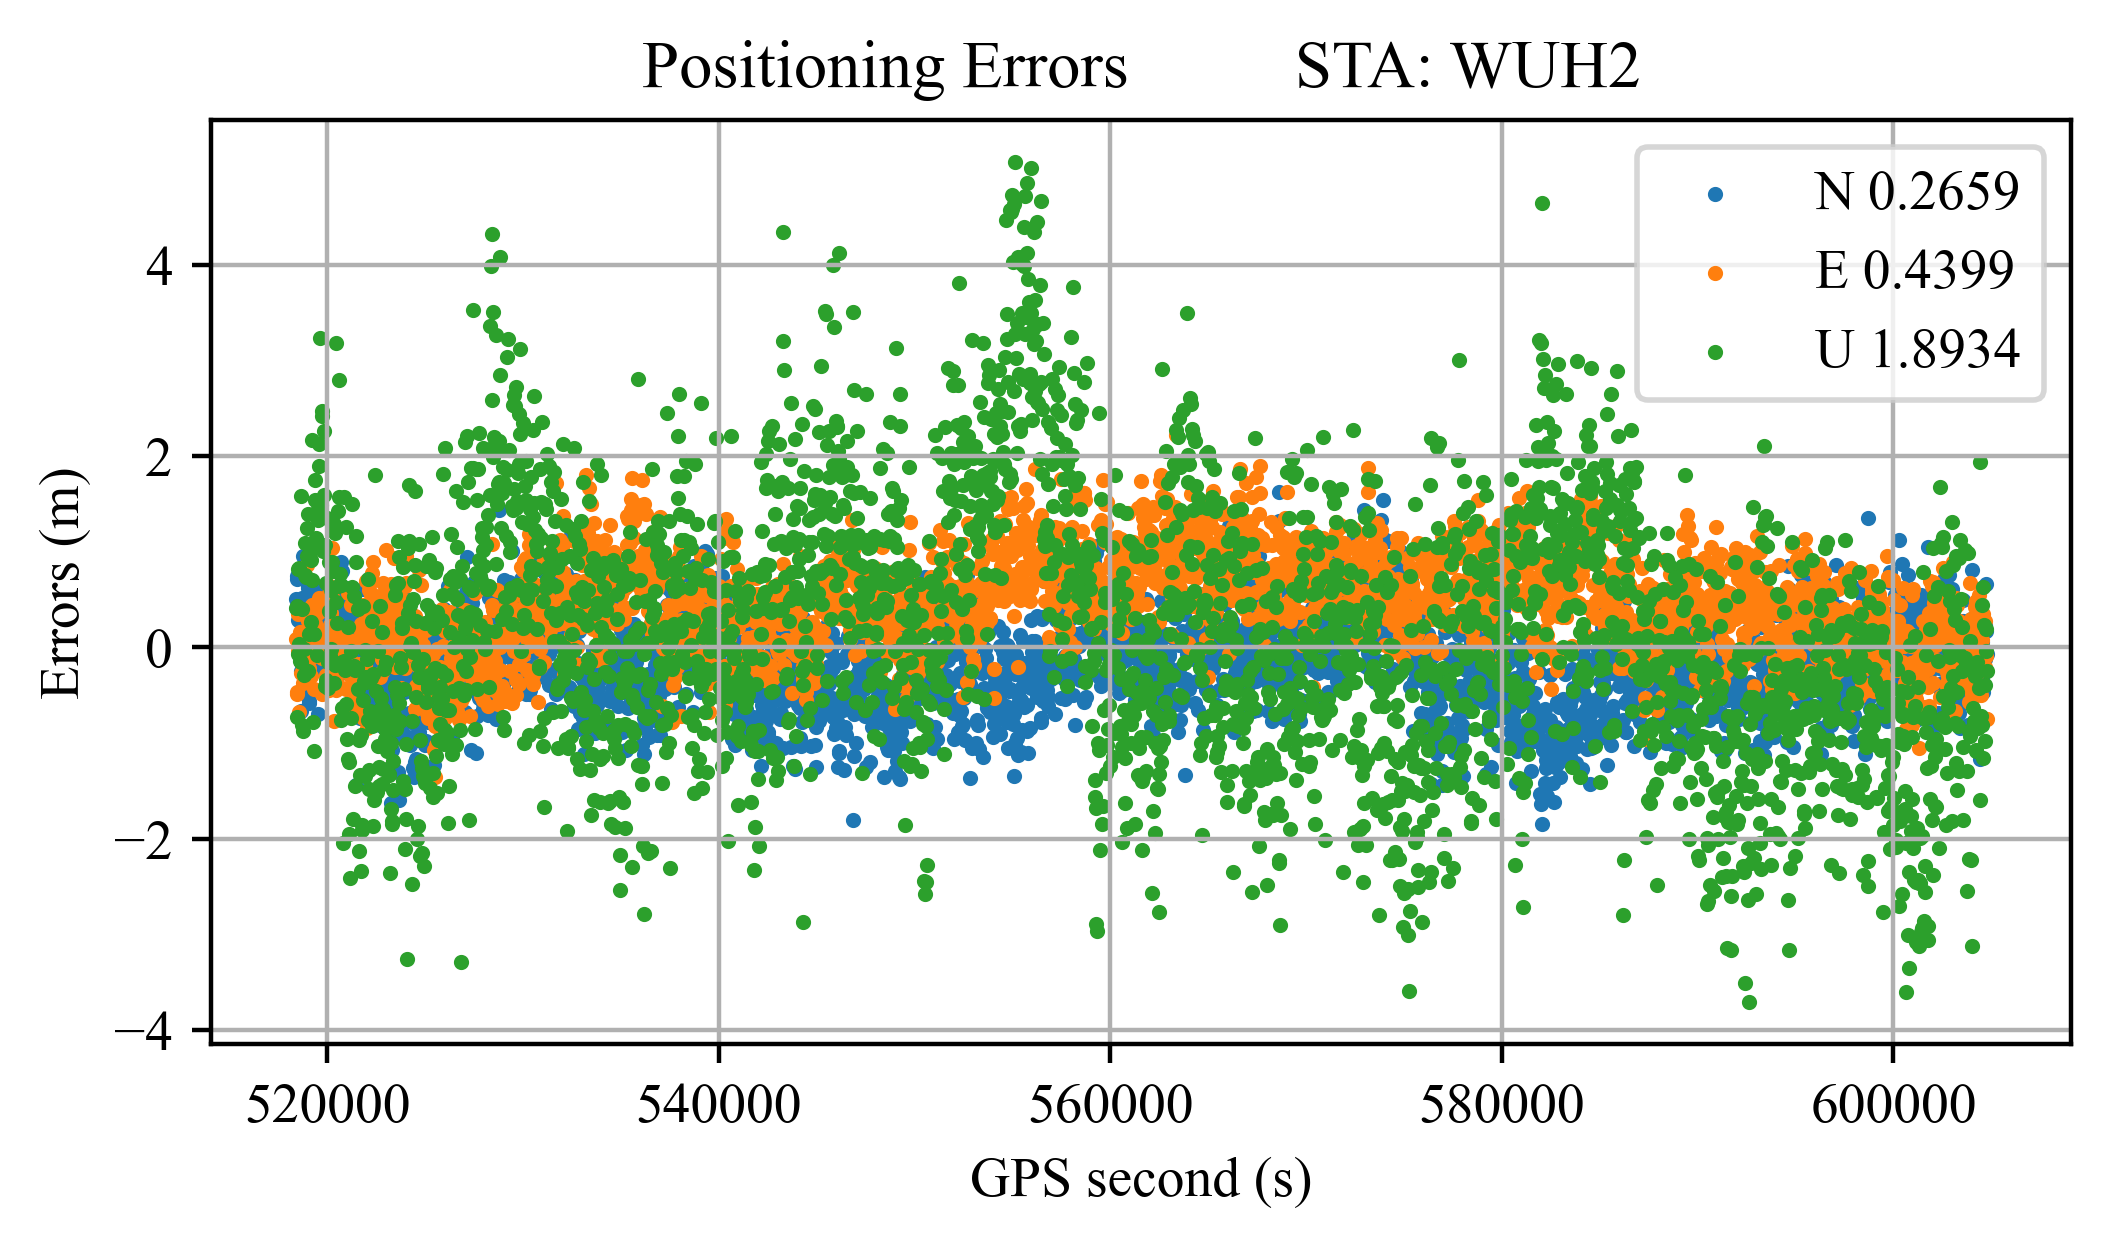

In [38]:
#绘图 SPP误差序列图
#设置或读取基准坐标ENU误差

#设置Solution logs文件路径
sol_log_f="nav_result/wuh21320.24o.out.npy"
SNX_CRD_f="data/SNX/IGS0OPSSNX_20241320000_01D_01D_CRD.SNX"
STA_name=""                                 #解算站点名称, 若空, 自动赋值为解算日志文件的前四位(依据RINEX V3文件命名规则)
ylim=[]                             #误差可视化纵轴范围, 对于PPP而言, ENU误差可视化一般设置为 -1.0m ~ 1.0m 左右较为适宜
STA=[]
if(STA_name==""):
    STA_name=sol_log_f.split('/')[-1][:4].upper()

sol_log=np.load(sol_log_f,allow_pickle=True)
if(STA==[]):
    STA=CRD_SNX2STA(SNX_CRD_f)[STA_name]
neu=[]
for x in sol_log:
    neu_x=xyz2neu([x[2],x[3],x[4]],STA)
    neu_n=np.linalg.norm(xyz2neu([x[2],x[3],x[4]],STA))
    neu.append([x[0],x[1],neu_x[0],neu_x[1],neu_x[2],neu_n])
neu=np.array(neu)

#绘图
plt.rcParams['font.sans-serif'] = ['Times New Roman']
plt.figure(dpi=400,facecolor="white",figsize=(6,3))
plt.scatter(neu[:,1],neu[:,2],s=3)
plt.scatter(neu[:,1],neu[:,3],s=3)
plt.scatter(neu[:,1],neu[:,4],s=3)
#plt.plot(neu[:,1],neu[:,5])
plt.grid('on')

def RMS(X):
    return sum((np.array(X))**2)/len(X)

plt.legend(["N {:.4f}".format(float(RMS(neu[:,2]))),"E {:.4f}".format(float(RMS(neu[:,3]))),"U {:.4f}".format(float(RMS(neu[:,4]))),"G {:.4f}".format(float(RMS(neu[:,5])))])

if(ylim!=[]):
    plt.ylim(ylim[0],ylim[1])
    
#plt.title("Easy4SPP Positioning Errors          STA: {}".format(STA_name))
plt.title("Positioning Errors          STA: {}".format(STA_name))
plt.xlabel("GPS second (s)")
plt.ylabel("Errors (m)")

Text(0, 0.5, 'Clock Bias (m)')

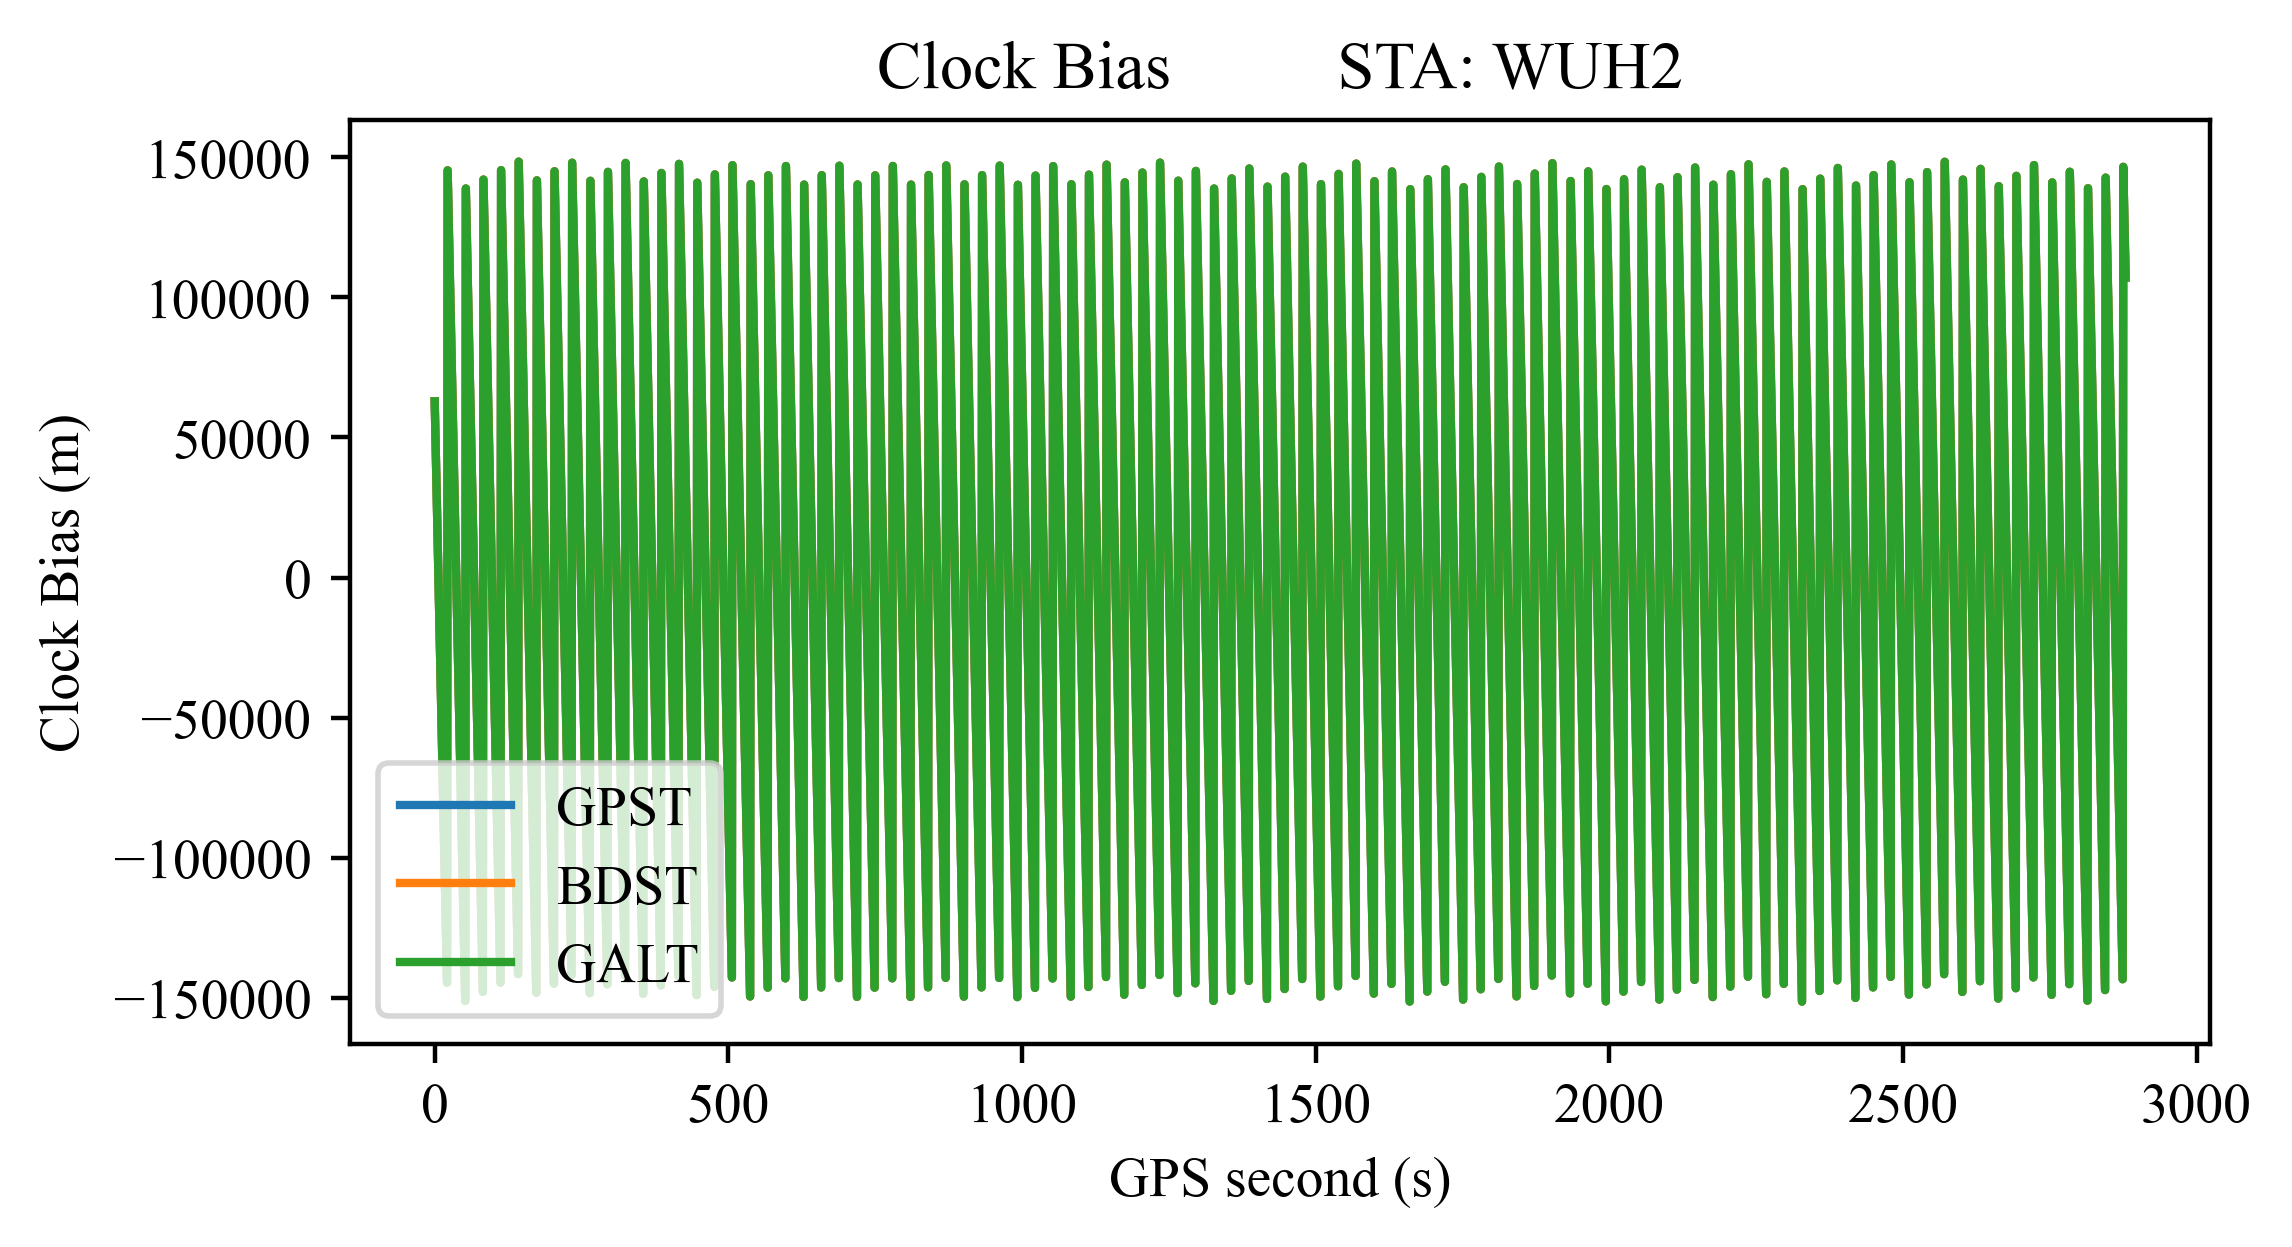

In [39]:
#钟差时序图
clk_series=np.array(sol_log)
show_index=['GPST','BDST','GALT']
#show_index=['GPS_ISB','BDS_ISB','GAL_ISB']

plt.figure(dpi=400,figsize=(6,3),facecolor='white')

for i in range(len(show_index)):
    if(show_index[i]=='GPST'):
        plt.plot(clk_series[:,5])
    if(show_index[i]=='BDST'):
        plt.plot(clk_series[:,6])
    if(show_index[i]=='GALT'):
        plt.plot(clk_series[:,7])
    if(show_index[i]=='GPS_ISB'):
        plt.plot(clk_series[:,5]-clk_series[:,5])
    if(show_index[i]=='BDS_ISB'):
        plt.plot(clk_series[:,6]-clk_series[:,5])
    if(show_index[i]=='GAL_ISB'):
        plt.plot(clk_series[:,7]-clk_series[:,5])
plt.legend(show_index)

plt.title("Clock Bias          STA: {}".format(STA_name))
plt.xlabel("GPS second (s)")
plt.ylabel("Clock Bias (m)")

In [40]:
#将Easy4SPP的结果转换为Easy4GINS松组合可输入的坐标文件格式
txt_path='Easy4SPP_Result_WUH2.txt'

with open(txt_path,'w') as f:
    for log in sol_log:
        b,l,h=xyz2blh(log[2],log[3],log[4])
        line='{:02d} {:.6f} {:.10f} {:.10f} {:.10f} {:.4f} {:.4f} {:.4f} {:.4f} {:.4f} {:.4f}\n'.format(int(log[-1]),log[1],b,l,h,0.0,0.0,0.0,log[8],log[9],log[10])
        f.write(line)